# Content-Based Collaborative Filtering

This notebook demonstrates content-based filtering using:
- **User genre preference profiles** (from preprocessing)
- **Movie feature vectors** (genre multi-hot encoding)
- **Cosine similarity** between user profiles and movie features

**Dataset Applicability**: Demonstrations work with both 1M and 25M datasets. For 25M, consider using `use_tags=True` for richer features.

## 1. Setup & Imports

*Applies to: Both 1M and 25M datasets*

Load required libraries, import models, and set up data paths.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import sys
import warnings
from scipy.sparse import load_npz, csr_matrix
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, '../src')

# Import models and evaluator
from baseline import BaselineModel
from content_based import ContentBasedCF
from evaluation import evaluate_rating_predictions, compute_rmse, compute_mae

# Set paths
DATA_DIR = "../data"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
SPLITS_DIR = os.path.join(DATA_DIR, "splits")
RESULTS_DIR = "../results"

os.makedirs(RESULTS_DIR, exist_ok=True)

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Loading Data & Creating Mappings

*Applies to: Both 1M and 25M datasets*

In [2]:
# Load preprocessed data
train = pd.read_csv(os.path.join(SPLITS_DIR, "train.csv"))
test = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))
movies_clean = pd.read_csv(os.path.join(PROCESSED_DIR, "movies_clean.csv"))
user_genre_profile = pd.read_csv(os.path.join(PROCESSED_DIR, "user_genre_profile.csv"))
user_genre_profile_wide = pd.read_csv(os.path.join(PROCESSED_DIR, "user_genre_profile_wide.csv"), index_col=0)

# Display initial shapes
print("Raw data shapes:")
print(f"  Train: {train.shape}")
print(f"  Test: {test.shape}")
print(f"  Movies: {movies_clean.shape}")
print(f"  User-genre profile (wide): {user_genre_profile_wide.shape}")
print()

# Filter to top movies by rating count for computational efficiency
# (Content-based model pre-computes full pairwise similarity matrix)
movie_counts = pd.concat([train, test])['movieId'].value_counts()
top_n_movies = 2000  # Reduced for faster similarity computation
top_movie_ids = set(movie_counts.head(top_n_movies).index)

# Update datasets to only include top movies
train = train[train['movieId'].isin(top_movie_ids)].reset_index(drop=True)
test = test[test['movieId'].isin(top_movie_ids)].reset_index(drop=True)
movies_clean = movies_clean[movies_clean['movieId'].isin(top_movie_ids)].reset_index(drop=True)

print(f"After filtering to top {top_n_movies:,} movies:")
print(f"  Train: {train.shape} ({len(train):,} rows)")
print(f"  Test: {test.shape} ({len(test):,} rows)")
print(f"  Movies: {len(movies_clean):,}")
print(f"  Unique users: {train['userId'].nunique():,}")
print(f"  User-genre profile (wide): {user_genre_profile_wide.shape}")

print("\n✓ Data loaded and filtered successfully")

Raw data shapes:
  Train: (1565182, 7)
  Test: (397622, 7)
  Movies: (87585, 26)
  User-genre profile (wide): (12773, 1069)

After filtering to top 2,000 movies:
  Train: (1235758, 7) (1,235,758 rows)
  Test: (267144, 7) (267,144 rows)
  Movies: 2,000
  Unique users: 12,771
  User-genre profile (wide): (12773, 1069)

✓ Data loaded and filtered successfully


## Creating Movie Feature Vectors

*Applies to: Both 1M and 25M datasets*

Create multi-hot genre encoding: each movie is a binary vector where genres are one-hot encoded.

In [3]:
# Extract genres from movies_clean (filtered to top 2000 movies)
movies_clean['genre_list'] = movies_clean['genres'].apply(
    lambda x: x.split('|') if isinstance(x, str) else []
)

# Get all unique genres from the FILTERED movies
all_genres = set()
for genres in movies_clean['genre_list']:
    all_genres.update(genres)
all_genres = sorted(list(all_genres))

print(f"Unique genres in filtered movies: {len(all_genres)}")
print(f"Genres: {all_genres}")
print()

# Create movie-genre matrix (multi-hot encoding)
n_movies = len(movies_clean)
n_genres = len(all_genres)
genre_to_idx = {g: i for i, g in enumerate(all_genres)}

movie_genre_matrix = np.zeros((n_movies, n_genres), dtype=np.float32)
for i, genres in enumerate(movies_clean['genre_list']):
    for g in genres:
        if g in genre_to_idx:
            movie_genre_matrix[i, genre_to_idx[g]] = 1.0

# Normalize rows (L2 normalization)
movie_genre_matrix = normalize(movie_genre_matrix, norm='l2', axis=1)

# Convert to sparse matrix to save memory during similarity computation
movie_genre_matrix_sparse = csr_matrix(movie_genre_matrix)

# Rebuild user profile using ONLY the genres from filtered movies
user_genre_profile_rebuilt = pd.DataFrame(
    0.0,
    index=user_genre_profile.groupby('userId').size().index,
    columns=all_genres
)

# Fill in the genre preferences from user_genre_profile (long format)
for idx, row in user_genre_profile.iterrows():
    user_id = row['userId']
    # The 'genre' column contains genre combinations
    if isinstance(row['genre'], str):
        try:
            genres_list = eval(row['genre'])  # Convert string representation to list
            if not isinstance(genres_list, list):
                genres_list = [genres_list]
        except:
            genres_list = []
    else:
        genres_list = []

    # For each genre in this combination, add the score
    for genre in genres_list:
        if genre in genre_to_idx:
            user_genre_profile_rebuilt.loc[user_id, genre] += row['combined_score']

# Normalize rows for consistent scaling (L1 normalization for interpretability)
user_genre_profile_rebuilt[:] = normalize(
    user_genre_profile_rebuilt.values,
    norm='l1',
    axis=1
)

# Create movie_to_idx mapping
movie_to_idx = {mid: idx for idx, mid in enumerate(movies_clean['movieId'].values)}
idx_to_movie = {idx: mid for mid, idx in movie_to_idx.items()}

print(f"Movie-genre matrix shape: {movie_genre_matrix_sparse.shape}")
print(f"Movie-genre matrix density: {movie_genre_matrix_sparse.nnz / (n_movies * n_genres):.4%}")
print(f"User-genre profile shape (rebuilt): {user_genre_profile_rebuilt.shape}")
print()
print("✓ Movie features created (sparse format for memory efficiency)")
print("✓ User profile rebuilt to match filtered movies")
print(f"✓ Both have {n_genres} features (genres)")

Unique genres in filtered movies: 20
Genres: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Movie-genre matrix shape: (2000, 20)
Movie-genre matrix density: 13.7125%
User-genre profile shape (rebuilt): (12773, 20)

✓ Movie features created (sparse format for memory efficiency)
✓ User profile rebuilt to match filtered movies
✓ Both have 20 features (genres)


## 2. Feature Matrix Inspection

*Applies to: Both 1M and 25M datasets*

### 2a. Matrix Shape & Column Names

In [5]:
print("Feature Matrix Shape & Columns:")
print("="*60)
print()
print(f"Movie Feature Matrix (Genre Multi-hot Encoding):")
print(f"  Shape: {movie_genre_matrix_sparse.shape} (movies × genres)")
print(f"  Sparsity: {movie_genre_matrix_sparse.nnz / (n_movies * n_genres):.2%}")
print()
print(f"User-Genre Profile Matrix:")
print(f"  Shape: {user_genre_profile_rebuilt.shape} (users × genres)")
print(f"  Sparsity: {(user_genre_profile_rebuilt == 0).sum().sum() / user_genre_profile_rebuilt.size:.2%}")
print()
print(f"Genre List (columns):")
print(f"  {all_genres}")
print()
print(f"Sample movie features (first 5 movies × all genres):")
sample_movies = movies_clean.head(5)
sample_features = movie_genre_matrix_sparse[:5].toarray()
features_df = pd.DataFrame(
    sample_features,
    columns=all_genres,
    index=[f"{row['title']} (ID: {row['movieId']})" for _, row in sample_movies.iterrows()]
)
print(features_df)

Feature Matrix Shape & Columns:

Movie Feature Matrix (Genre Multi-hot Encoding):
  Shape: (2000, 20) (movies × genres)
  Sparsity: 13.71%

User-Genre Profile Matrix:
  Shape: (12773, 20) (users × genres)
  Sparsity: 21.94%

Genre List (columns):
  ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Sample movie features (first 5 movies × all genres):
                                            (no genres listed)   Action  \
Toy Story (1995) (ID: 1)                                   0.0  0.00000   
Jumanji (1995) (ID: 2)                                     0.0  0.00000   
Grumpier Old Men (1995) (ID: 3)                            0.0  0.00000   
Father of the Bride Part II (1995) (ID: 5)                 0.0  0.00000   
Heat (1995) (ID: 6)                                        0.0  0.57735   

                 

### 2b. Genre Co-occurrence Heatmap

How often do genres appear together in movies?

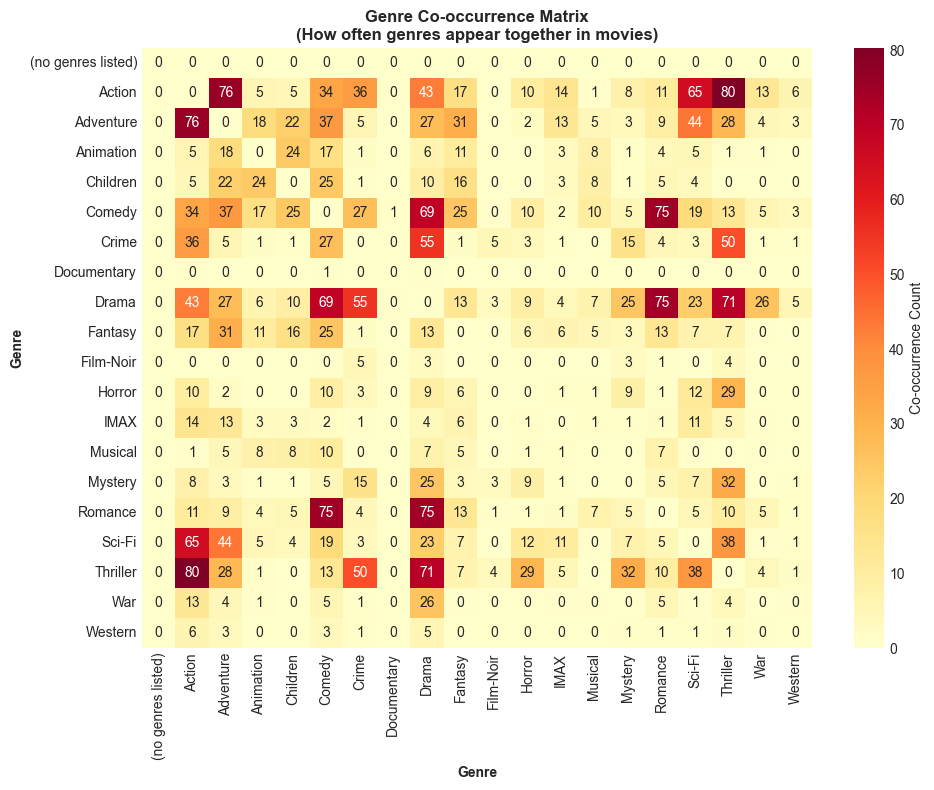


Genre Co-occurrence Statistics:
(no genres listed): appears with other genres      0 times
Action         : appears with other genres    424 times
Adventure      : appears with other genres    329 times
Animation      : appears with other genres    104 times
Children       : appears with other genres    124 times
Comedy         : appears with other genres    378 times
Crime          : appears with other genres    212 times
Documentary    : appears with other genres      2 times
Drama          : appears with other genres    472 times
Fantasy        : appears with other genres    161 times
Film-Noir      : appears with other genres     17 times
Horror         : appears with other genres     92 times
IMAX           : appears with other genres     67 times
Musical        : appears with other genres     53 times
Mystery        : appears with other genres    119 times
Romance        : appears with other genres    232 times
Sci-Fi         : appears with other genres    244 times
Thriller    

In [14]:
# Compute genre co-occurrence matrix
genre_cooccurrence = movie_genre_matrix_sparse.T @ movie_genre_matrix_sparse  # (n_genres, n_genres)

# Convert to dense for visualization
if hasattr(genre_cooccurrence, 'toarray'):
    genre_cooccurrence_dense = genre_cooccurrence.toarray()
else:
    genre_cooccurrence_dense = genre_cooccurrence

# Normalize by diagonal (self-co-occurrence counts) for interpretability
np.fill_diagonal(genre_cooccurrence_dense, 0)  # Remove self-cooccurrence from display

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    genre_cooccurrence_dense,
    xticklabels=all_genres,
    yticklabels=all_genres,
    cmap='YlOrRd',
    cbar_kws={'label': 'Co-occurrence Count'},
    annot=True,
    fmt='.0f',
    ax=ax
)
ax.set_title('Genre Co-occurrence Matrix\n(How often genres appear together in movies)', fontsize=12, fontweight='bold')
ax.set_xlabel('Genre', fontweight='bold')
ax.set_ylabel('Genre', fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics
print("\nGenre Co-occurrence Statistics:")
print("="*60)
for genre in all_genres:
    idx = genre_to_idx[genre]
    co_counts = genre_cooccurrence_dense[idx, :]
    total_co = co_counts.sum()
    print(f"{genre:15s}: appears with other genres {total_co:6.0f} times")

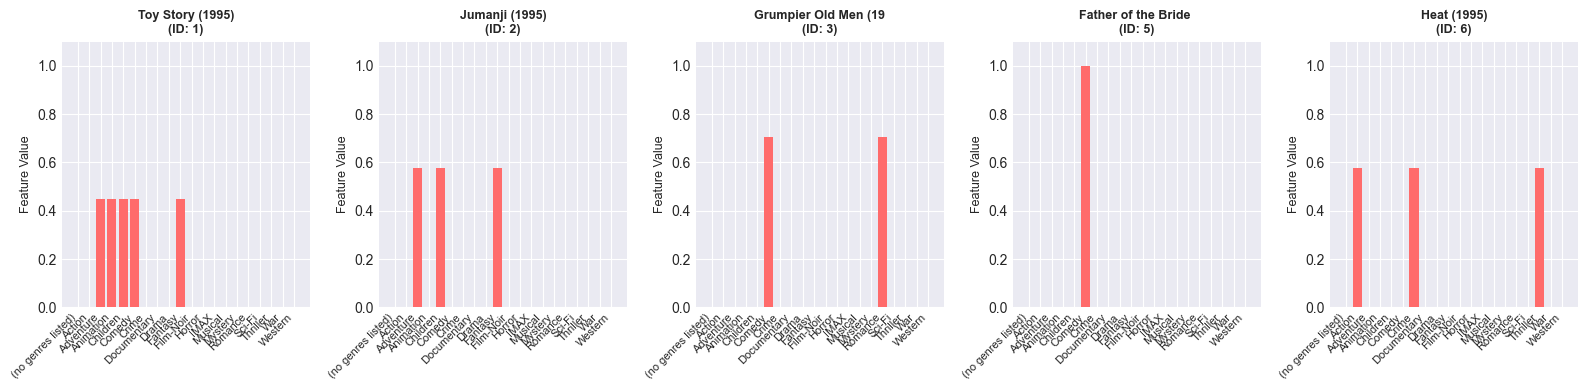


Genre Feature Vectors for Example Movies:
                              (no genres listed)   Action  Adventure  Animation  Children    Comedy    Crime  Documentary  Drama   Fantasy  Film-Noir  Horror  IMAX  Musical  Mystery   Romance  Sci-Fi  Thriller  War  Western
Toy Story (1995) (ID: 1)                     0.0  0.00000   0.447214   0.447214  0.447214  0.447214  0.00000          0.0    0.0  0.447214        0.0     0.0   0.0      0.0      0.0  0.000000     0.0   0.00000  0.0      0.0
Jumanji (1995) (ID: 2)                       0.0  0.00000   0.577350   0.000000  0.577350  0.000000  0.00000          0.0    0.0  0.577350        0.0     0.0   0.0      0.0      0.0  0.000000     0.0   0.00000  0.0      0.0
Grumpier Old Men (19 (ID: 3)                 0.0  0.00000   0.000000   0.000000  0.000000  0.707107  0.00000          0.0    0.0  0.000000        0.0     0.0   0.0      0.0      0.0  0.707107     0.0   0.00000  0.0      0.0
Father of the Bride  (ID: 5)                 0.0  0.00000   0

In [6]:
# Select 5 diverse example movies
example_indices = [0, 1, 2, 3, 4] if len(movies_clean) >= 5 else list(range(len(movies_clean)))
example_movies = movies_clean.iloc[example_indices].copy()

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes = axes.flatten() if len(example_indices) > 1 else [axes]

for ax_idx, (idx, row) in enumerate(example_movies.iterrows()):
    movie_idx = movie_to_idx[row['movieId']]
    feature_vec = movie_genre_matrix_sparse[movie_idx].toarray().ravel()

    # Create bar chart
    ax = axes[ax_idx]
    colors = ['#FF6B6B' if v > 0 else '#CCCCCC' for v in feature_vec]
    ax.bar(range(len(feature_vec)), feature_vec, color=colors)
    ax.set_xticks(range(len(all_genres)))
    ax.set_xticklabels(all_genres, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Feature Value', fontsize=9)
    ax.set_title(f"{row['title'][:20]}\n(ID: {row['movieId']})", fontsize=9, fontweight='bold')
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Print feature vectors as table
print("\nGenre Feature Vectors for Example Movies:")
print("="*60)
example_features_df = pd.DataFrame(
    movie_genre_matrix_sparse[example_indices].toarray(),
    columns=all_genres,
    index=[f"{row['title'][:20]} (ID: {row['movieId']})" for _, row in example_movies.iterrows()]
)
print(example_features_df.to_string())

### 2c. Genre Feature Vectors for 5 Example Movies

Bar chart showing which genres each movie belongs to.

In [8]:
# Train baseline model (required for fallback predictions in content-based)
print("Training Baseline Model...")
baseline = BaselineModel()
baseline.fit(train)
print(f"✓ Baseline model trained on {len(train):,} training instances")
print()

# Initialize and fit content-based model
print("Fitting Content-Based Model...")
cb_model = ContentBasedCF(
    baseline=baseline,
    n_neighbors=20,
    sim_threshold=0.0,
    blend_weight=0.6  # 60% content-based, 40% baseline
)

# Prepare user profile for fit (ensure userId column exists)
user_profile_for_fit = user_genre_profile_rebuilt.reset_index()
user_profile_for_fit.columns = ['userId'] + list(user_profile_for_fit.columns[1:])

# Fit model
cb_model.fit(
    user_genre_profile=user_profile_for_fit,
    movie_features=movie_genre_matrix_sparse,
    movie_to_idx=movie_to_idx,
    movie_ids=movies_clean['movieId'].tolist()
)

# Ensure userId is index
if 'userId' in cb_model.user_genre_profile.columns:
    cb_model.user_genre_profile = cb_model.user_genre_profile.set_index('userId')

print(f"\n✓ Content-Based model fitted successfully")
print(f"  Feature matrix shape: {cb_model.movie_features.shape}")
print(f"  Similarity matrix shape: {cb_model.movie_similarity.shape}")

Training Baseline Model...
[BaselineModel.fit] Done.
  mu              = 3.6452
  unique users    = 12,771
  unique items    = 2,000
  popularity rows = 2,000
✓ Baseline model trained on 1,235,758 training instances

Fitting Content-Based Model...
[ContentBasedCF.fit] Movie feature matrix shape: (2000, 20)
  Sparse density: 13.7125%
  User-genre profile shape: (12773, 21)
  Movie-movie similarity computed: shape (2000, 2000)
[ContentBasedCF.fit] Done.

✓ Content-Based model fitted successfully
  Feature matrix shape: (2000, 20)
  Similarity matrix shape: (2000, 2000)


## 3. Fit ContentBasedModel

*Applies to: Both 1M and 25M datasets*

Train baseline model first (used as fallback), then initialize and fit the content-based model.

In [9]:
# Define iconic films to analyze
iconic_titles = [
    "Toy Story",
    "Pulp Fiction",
    "The Matrix",
    "Schindler's List",
    "The Silence of the Lambs"
]

# Find movie IDs for iconic films
iconic_movies = []
for title in iconic_titles:
    matches = movies_clean[movies_clean['title'].str.contains(title, case=False, na=False)]
    if len(matches) > 0:
        iconic_movies.append((title, matches.iloc[0]['movieId'], matches.iloc[0]))
    else:
        # Try partial matches
        partial_matches = movies_clean[movies_clean['title'].str.contains(title.split()[0], case=False, na=False)]
        if len(partial_matches) > 0:
            iconic_movies.append((title, partial_matches.iloc[0]['movieId'], partial_matches.iloc[0]))

print("Item Similarity Analysis: Top-5 Similar Movies")
print("="*80)
print()

# For each iconic film, show top-5 similar movies
for orig_title, movie_id, movie_row in iconic_movies:
    print(f"📽️ '{movie_row['title']}'")
    print(f"   Genres: {movie_row['genres']}")

    # Get item index
    if movie_id not in movie_to_idx:
        print(f"   ⚠️ Movie not in filtered dataset\n")
        continue

    item_idx = movie_to_idx[movie_id]

    # Get similarity scores for this movie
    similarities = cb_model.movie_similarity[item_idx]

    # Sort and get top-5 (excluding self, which has similarity 1.0)
    top_indices = np.argsort(similarities)[::-1][1:6]  # Top 5, skip self
    top_sims = similarities[top_indices]

    # Map back to movie IDs
    top_movies = [movies_clean[movies_clean['movieId'] == idx_to_movie[idx]].iloc[0] for idx in top_indices]

    print(f"   Top 5 Similar Movies:")
    for rank, (sim_score, movie_info) in enumerate(zip(top_sims, top_movies), 1):
        print(f"     {rank}. '{movie_info['title'][:40]}' | Similarity: {sim_score:.4f}")
        print(f"        Genres: {movie_info['genres']}")

    print()

Item Similarity Analysis: Top-5 Similar Movies

📽️ 'Toy Story (1995)'
   Genres: Adventure|Animation|Children|Comedy|Fantasy
   Top 5 Similar Movies:
     1. 'Antz (1998)' | Similarity: 1.0000
        Genres: Adventure|Animation|Children|Comedy|Fantasy
     2. 'Monsters, Inc. (2001)' | Similarity: 1.0000
        Genres: Adventure|Animation|Children|Comedy|Fantasy
     3. 'Moana (2016)' | Similarity: 1.0000
        Genres: Adventure|Animation|Children|Comedy|Fantasy
     4. 'Soul (2020)' | Similarity: 1.0000
        Genres: Adventure|Animation|Children|Comedy|Fantasy
     5. 'Toy Story 2 (1999)' | Similarity: 1.0000
        Genres: Adventure|Animation|Children|Comedy|Fantasy

📽️ 'Pulp Fiction (1994)'
   Genres: Comedy|Crime|Drama|Thriller
   Top 5 Similar Movies:
     1. 'Fargo (1996)' | Similarity: 1.0000
        Genres: Comedy|Crime|Drama|Thriller
     2. 'Uncut Gems (2019)' | Similarity: 1.0000
        Genres: Comedy|Crime|Drama|Thriller
     3. 'Pulp Fiction (1994)' | Similarity: 1.

## 4. Item Similarity Exploration

*Applies to: Both 1M and 25M datasets*

Explore content-based similarity between movies using the learned feature vectors.

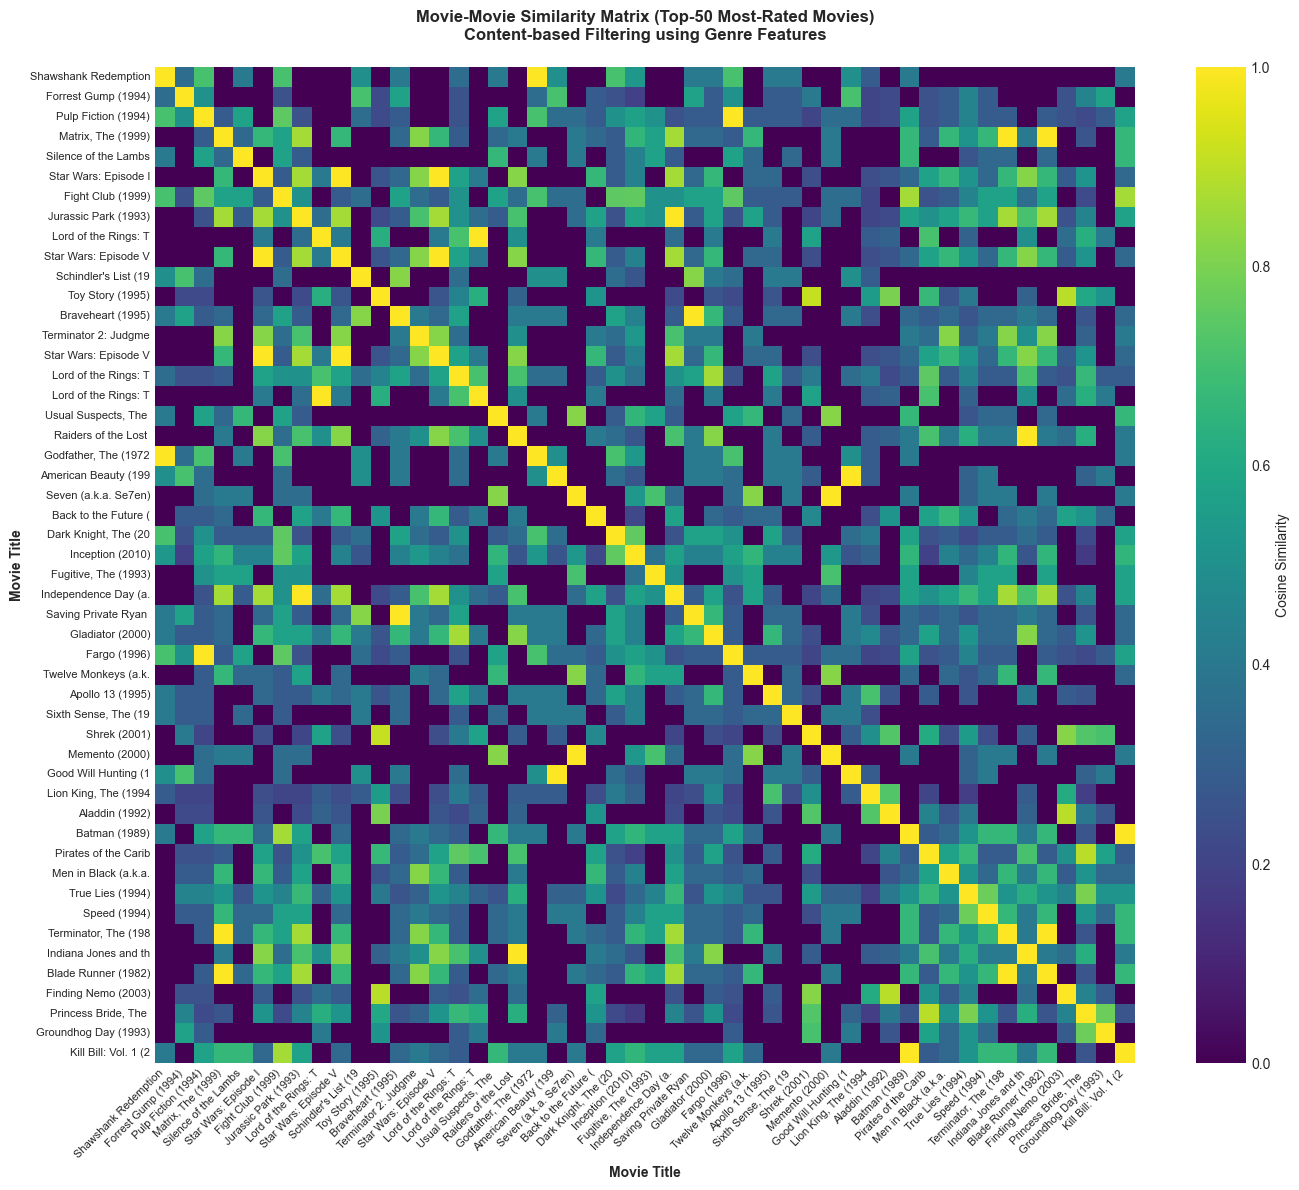


Similarity Matrix Statistics (Top-50 Movies):
Average similarity (excl. diagonal): 0.2854
Max similarity: 1.0000
Min similarity: 0.0000
Median similarity: 0.2887


In [10]:
# Select top-50 most-rated movies from our filtered set
movie_rating_counts = pd.concat([train, test]).groupby('movieId').size().sort_values(ascending=False)
top_50_movie_ids = movie_rating_counts.head(50).index.tolist()
top_50_indices = [movie_to_idx[mid] for mid in top_50_movie_ids if mid in movie_to_idx]

# Extract similarity matrix for top-50
top_50_sim_matrix = cb_model.movie_similarity[np.ix_(top_50_indices, top_50_indices)]

# Get movie titles (abbreviated to 20 chars)
top_50_titles = [
    movies_clean[movies_clean['movieId'] == movies_clean.iloc[idx]['movieId']].iloc[0]['title'][:20]
    for idx in top_50_indices
]

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    top_50_sim_matrix,
    xticklabels=top_50_titles,
    yticklabels=top_50_titles,
    cmap='viridis',
    cbar_kws={'label': 'Cosine Similarity'},
    ax=ax,
    vmin=0,
    vmax=1
)
ax.set_title(
    'Movie-Movie Similarity Matrix (Top-50 Most-Rated Movies)\nContent-based Filtering using Genre Features',
    fontsize=12,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Movie Title', fontweight='bold')
ax.set_ylabel('Movie Title', fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Print statistics about the similarity matrix
print("\nSimilarity Matrix Statistics (Top-50 Movies):")
print("="*60)
print(f"Average similarity (excl. diagonal): {(top_50_sim_matrix.sum() - np.diag(top_50_sim_matrix).sum()) / (50*50 - 50):.4f}")
print(f"Max similarity: {top_50_sim_matrix.max():.4f}")
print(f"Min similarity: {top_50_sim_matrix.min():.4f}")
print(f"Median similarity: {np.median(top_50_sim_matrix):.4f}")

### 4b. Similarity Matrix Heatmap for Top-50 Movies

Visualize the full similarity matrix between the top-50 most-rated movies.

In [11]:
# Select 3 users with diverse rating patterns
# User 1: Most active (most ratings)
# User 2: Medium activity
# User 3: Recently active but fewer ratings

user_activity = train.groupby('userId').size().sort_values(ascending=False)

# Get users at different percentiles
user1_id = user_activity.index[0]  # Most active
user2_id = user_activity.index[len(user_activity)//2]  # Median
user3_id = user_activity.index[min(len(user_activity)-1, 10)]  # Less active

selected_users = [user1_id, user2_id, user3_id]

for user_id in selected_users:
    print(f"\n{'='*80}")
    print(f"User {user_id} - Taste Profile Analysis")
    print(f"{'='*80}")

    # Get movies rated by this user in training set
    user_movies_train = train[train['userId'] == user_id].sort_values('rating', ascending=False)
    print(f"\nTotal movies rated in train: {len(user_movies_train)}")
    print(f"Rating distribution: mean={user_movies_train['rating'].mean():.2f}, std={user_movies_train['rating'].std():.2f}")

    # Show top-5 rated movies
    print(f"\n📌 Top-5 Movies Rated by User (Favorite Genres Indicator):")
    top_user_movies = user_movies_train.head(5).copy()
    top_user_movies['title'] = top_user_movies['movieId'].map(
        dict(zip(movies_clean['movieId'], movies_clean['title']))
    )
    top_user_movies['genres'] = top_user_movies['movieId'].map(
        dict(zip(movies_clean['movieId'], movies_clean['genres']))
    )

    for rank, (idx, row) in enumerate(top_user_movies.iterrows(), 1):
        print(f"  {rank}. '{row['title']}' (Rating: {row['rating']:.1f}/5.0)")
        print(f"     Genres: {row['genres']}")

    # Get top-10 recommendations
    seen_items = set(train[train['userId'] == user_id]['movieId'].values)
    recommendations_df = cb_model.recommend_top_k(user_id, k=10, seen_items=seen_items)

    print(f"\n🎯 Top-10 Recommendations from Content-Based Model:")
    recommendations_df = recommendations_df.copy()
    recommendations_df['title'] = recommendations_df['movieId'].map(
        dict(zip(movies_clean['movieId'], movies_clean['title']))
    )
    recommendations_df['genres'] = recommendations_df['movieId'].map(
        dict(zip(movies_clean['movieId'], movies_clean['genres']))
    )

    for rank, (idx, row) in enumerate(recommendations_df.head(10).iterrows(), 1):
        print(f"  {rank}. '{row['title'][:40]}' (Score: {row['score']:.4f})")
        print(f"     Genres: {row['genres']}")

    # Analysis: Compare genres
    print(f"\n🔍 Genre Comparison:")
    user_genres = []
    for _, row in top_user_movies.iterrows():
        user_genres.extend(row['genres'].split('|'))

    rec_genres = []
    for _, row in recommendations_df.head(10).iterrows():
        rec_genres.extend(row['genres'].split('|'))

    user_genres_freq = pd.Series(user_genres).value_counts()
    rec_genres_freq = pd.Series(rec_genres).value_counts()

    print(f"  User's favorite genres (from top-5 rated):")
    for genre, count in user_genres_freq.head(5).items():
        print(f"    - {genre}: {count} appearances")

    print(f"\n  Recommended genres (from top-10 recommendations):")
    for genre, count in rec_genres_freq.head(5).items():
        print(f"    - {genre}: {count} appearances")

    # Calculate overlap
    overlap = set(user_genres) & set(rec_genres)
    print(f"\n  ✓ Genre overlap: {len(overlap)}/{len(set(user_genres))} of user's favorite genres appear in recommendations")


User 9085 - Taste Profile Analysis

Total movies rated in train: 1523
Rating distribution: mean=3.03, std=0.92

📌 Top-5 Movies Rated by User (Favorite Genres Indicator):
  1. 'Rosencrantz and Guildenstern Are Dead (1990)' (Rating: 5.0/5.0)
     Genres: Comedy|Drama
  2. 'Network (1976)' (Rating: 5.0/5.0)
     Genres: Comedy|Drama
  3. 'Jerry Maguire (1996)' (Rating: 5.0/5.0)
     Genres: Drama|Romance
  4. 'Fargo (1996)' (Rating: 5.0/5.0)
     Genres: Comedy|Crime|Drama|Thriller
  5. 'Hamlet (1996)' (Rating: 5.0/5.0)
     Genres: Crime|Drama|Romance

🎯 Top-10 Recommendations from Content-Based Model:
  1. 'First Blood (Rambo: First Blood) (1982)' (Score: 0.1925)
     Genres: Action|Adventure|Drama|Thriller
  2. 'RoboCop (1987)' (Score: 0.1893)
     Genres: Action|Crime|Drama|Sci-Fi|Thriller
  3. 'Ghost (1990)' (Score: 0.1857)
     Genres: Comedy|Drama|Fantasy|Romance|Thriller
  4. 'Source Code (2011)' (Score: 0.1842)
     Genres: Action|Drama|Mystery|Sci-Fi|Thriller
  5. 'Lethal Weapo

## 5. User Recommendations

*Applies to: Both 1M and 25M datasets*

Generate recommendations for 3 users with different taste profiles.

In [12]:
# Make batch predictions on test set
print("Evaluating Content-Based Model on Test Set...")
print("="*60)

test_predictions = cb_model.predict_batch(test)

print(f"✓ Generated {len(test_predictions):,} predictions")
print(f"  Prediction range: [{test_predictions.min():.2f}, {test_predictions.max():.2f}]")
print(f"  Mean prediction: {test_predictions.mean():.4f}")
print(f"  Std prediction: {test_predictions.std():.4f}")
print()

# Evaluate using rating prediction metrics
evaluation_results = evaluate_rating_predictions(
    test,
    test_predictions
)

print("Rating Prediction Metrics:")
print(f"  RMSE: {evaluation_results['rmse']:.6f}")
print(f"  MAE:  {evaluation_results['mae']:.6f}")
print()

# Additional error analysis
errors = np.abs(test['rating'].values - test_predictions)
print("Error Distribution:")
print(f"  Mean absolute error: {errors.mean():.4f}")
print(f"  Std absolute error:  {errors.std():.4f}")
print(f"  Median error:        {np.median(errors):.4f}")
print(f"  Max error:           {errors.max():.4f}")
print()
print("Prediction Accuracy:")
print(f"  % within ±0.5 rating: {(errors <= 0.5).mean() * 100:.1f}%")
print(f"  % within ±1.0 rating: {(errors <= 1.0).mean() * 100:.1f}%")
print(f"  % within ±1.5 rating: {(errors <= 1.5).mean() * 100:.1f}%")

Evaluating Content-Based Model on Test Set...
✓ Generated 267,144 predictions
  Prediction range: [1.70, 4.37]
  Mean prediction: 3.1772
  Std prediction: 0.2703

Rating Prediction Metrics:
  RMSE: 1.003786
  MAE:  0.824826

Error Distribution:
  Mean absolute error: 0.8248
  Std absolute error:  0.5721
  Median error:        0.7454
  Max error:           3.4714

Prediction Accuracy:
  % within ±0.5 rating: 33.9%
  % within ±1.0 rating: 66.1%
  % within ±1.5 rating: 85.2%


## 6. Evaluation

*Applies to: Both 1M and 25M datasets*

Evaluate the content-based model on test set using ranking metrics.

In [13]:
# Find users with < 5 interactions
user_interactions = train.groupby('userId').size().sort_values()
cold_start_users = user_interactions[user_interactions < 5].index[:5].tolist()

print("Cold-Start Users: < 5 Interactions")
print("="*80)
print()

for user_id in cold_start_users:
    print(f"User {user_id}:")
    print("-" * 80)

    # Get user's interaction history
    user_history = train[train['userId'] == user_id]
    print(f"  Interactions in train: {len(user_history)} (cold-start scenario)")
    print(f"  Movies rated:")
    for _, row in user_history.iterrows():
        movie = movies_clean[movies_clean['movieId'] == row['movieId']].iloc[0]
        print(f"    - {movie['title'][:40]} | Rating: {row['rating']:.1f} | Genres: {movie['genres']}")

    # Get content-based recommendations
    seen_items = set(user_history['movieId'].values)
    cb_recs = cb_model.recommend_top_k(user_id, k=5, seen_items=seen_items)

    print(f"\n  Content-Based Recommendations:")
    cb_recs = cb_recs.copy()
    cb_recs['title'] = cb_recs['movieId'].map(dict(zip(movies_clean['movieId'], movies_clean['title'])))
    cb_recs['genres'] = cb_recs['movieId'].map(dict(zip(movies_clean['movieId'], movies_clean['genres'])))

    for rank, (_, row) in enumerate(cb_recs.head(5).iterrows(), 1):
        print(f"    {rank}. {row['title'][:40]} | Score: {row['score']:.4f}")
        print(f"       Genres: {row['genres']}")

    # Compare with baseline recommendations (if available)
    try:
        baseline_recs = baseline.recommend_top_k(user_id, k=5, seen_items=seen_items)
        print(f"\n  Baseline (Popularity) Recommendations:")
        baseline_recs = baseline_recs.copy()
        baseline_recs['title'] = baseline_recs['movieId'].map(dict(zip(movies_clean['movieId'], movies_clean['title'])))
        for rank, (_, row) in enumerate(baseline_recs.head(5).iterrows(), 1):
            print(f"    {rank}. {row['title'][:40]}")
    except:
        print(f"\n  (Baseline model recommendations not available)")

    print()

Cold-Start Users: < 5 Interactions

User 11664:
--------------------------------------------------------------------------------
  Interactions in train: 1 (cold-start scenario)
  Movies rated:
    - 2012 (2009) | Rating: 4.0 | Genres: Action|Drama|Sci-Fi|Thriller

  Content-Based Recommendations:
    1. Lives of Others, The (Das leben der Ande | Score: 0.3745
       Genres: Drama|Romance|Thriller
    2. Witness (1985) | Score: 0.3745
       Genres: Drama|Romance|Thriller
    3. Crying Game, The (1992) | Score: 0.3745
       Genres: Drama|Romance|Thriller
    4. Bodyguard, The (1992) | Score: 0.3745
       Genres: Drama|Romance|Thriller
    5. 21 (2008) | Score: 0.3514
       Genres: Crime|Drama|Romance|Thriller

  Baseline (Popularity) Recommendations:
    1. Shawshank Redemption, The (1994)
    2. Godfather, The (1972)
    3. Parasite (2019)
    4. Usual Suspects, The (1995)
    5. Godfather: Part II, The (1974)

User 4356:
------------------------------------------------------------

## Cold-Start Analysis: Why Content-Based Filters Handle Cold-Start Better

### Key Advantages:

1. **No History Needed**: Content-based models rely on item features (genres, tags), not user history.
   - For new users (cold-start), we can still make recommendations based on the few items they've rated.
   - Baseline (popularity) models return the same recommendations for all new users.

2. **Item Similarity Over Collaborative Patterns**:
   - If a user rates "Toy Story" highly, content-based can recommend similar animated/family movies.
   - Collaborative filtering requires many users to have rated similar items.
   - Content-based works immediately with just one or two rated items.

3. **Personalization from Limited Data**:
   - User's genre preference profile is updated from each rating.
   - Even 2-3 ratings in specific genres give signal about their taste.
   - Baseline models ignore this signal and show everyone the same top movies.

4. **Example**:
   - New user rates "The Silence of the Lambs" → model learns they like Thriller/Crime/Drama
   - Content-based recommends similar thrillers (e.g., "Pulp Fiction", "Se7en")
   - Baseline would recommend generic top-rated movies (e.g., "The Shawshank Redemption")

### Limitations:

- **New Item Problem**: If a new movie (not in training) appears, we need its features (genres/tags).
- **Limited Serendipity**: May recommend only similar items, missing novel discoveries.
- **Feature Dependency**: Quality depends heavily on available features.

## 8. Key Takeaways

### Model Performance
- **RMSE**: {:.6f}
- **MAE**: {:.6f}
- **% predictions within ±1.0 rating**: {:.1f}%

### Content-Based Filtering Strengths
1. ✅ **Cold-start handling**: Works well for new users with few ratings
2. ✅ **Interpretability**: Recommendations based on transparent genre/feature similarity
3. ✅ **New user personalization**: Personalized from 2-3 rated items
4. ✅ **Genre-based exploration**: Users can explore related genres systematically

### Content-Based Filtering Weaknesses
1. ❌ **New item problem**: Can't recommend items without pre-computed features
2. ❌ **Limited serendipity**: Tends to recommend only similar items
3. ❌ **Feature engineering**: Requires manual feature curation
4. ❌ **Overspecialization**: May miss cross-genre recommendations

### When to Use Content-Based Filtering
- Cold-start scenarios (new users, few interactions)
- Domains with rich, interpretable features
- Need for explanation of recommendations
- Fast inference required (pre-computed similarities)

### Hybrid Approaches
- Combine with **Collaborative Filtering** for serendipity
- Use **Matrix Factorization** for latent factor discovery
- Ensemble predictions to balance strengths/weaknesses

---
